In [2]:
import zipfile
import os

zip_path = "/projectnb/sparkgrp/dd4g-muckrock-patient-safety/deviceproblemcodes.zip"          
extract_to = "/projectnb/sparkgrp/dd4g-muckrock-patient-safety/extracted_problems"    

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_to)

print(f"Extracted {zip_path} to {extract_to}")

Extracted /projectnb/sparkgrp/dd4g-muckrock-patient-safety/deviceproblemcodes.zip to /projectnb/sparkgrp/dd4g-muckrock-patient-safety/extracted_problems


In [3]:
import pandas as pd

file_path = "/projectnb/sparkgrp/dd4g-muckrock-patient-safety/extracted_problems/deviceproblemcodes.csv"
df = pd.read_csv(file_path)

Exploratory Data Analysis (information about Problem Codes Columns)

In [4]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 882 entries, 0 to 881
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   FDA_CODE    882 non-null    int64 
 1   TERM        882 non-null    object
 2   NCIT_CODE   488 non-null    object
 3   IMDRF_CODE  488 non-null    object
dtypes: int64(1), object(3)
memory usage: 27.7+ KB
None


In [5]:
print(df.head())

   FDA_CODE                      TERM NCIT_CODE IMDRF_CODE
0         1     Old To Be Deactivated       NaN        NaN
1      1001   Failure To Run On AC/DC       NaN        NaN
2      1002                  Abnormal       NaN        NaN
3      1003                Absorption       NaN        NaN
4      1005  Measurements, inaccurate       NaN        NaN


In [6]:
print(df.columns)

Index(['FDA_CODE', 'TERM', 'NCIT_CODE', 'IMDRF_CODE'], dtype='object')


Column Keys: 

NCIT Code: represent standardized biomedical terms (device problems, symptoms, causes)

IMDRF Code: describing and classifying incidents related to medical devices

FDA Code: codes that assess effectiveness and safety of device

In [7]:
df['FDA_CODE'].value_counts().head(10)

FDA_CODE
3191    1
1       1
1001    1
1002    1
1003    1
1005    1
1006    1
1008    1
1010    1
1015    1
Name: count, dtype: int64

In [8]:
print(df['FDA_CODE'].unique()[:10])

[   1 1001 1002 1003 1005 1006 1008 1010 1015 1021]


In [9]:
df['NCIT_CODE'].value_counts().head(10)

NCIT_CODE
C64343     1
C133496    1
C62919     1
C63294     1
C62853     1
C62947     1
C62886     1
C63171     1
C72887     1
C63217     1
Name: count, dtype: int64

In [10]:
df['IMDRF_CODE'].value_counts().head(10)

IMDRF_CODE
A27        1
A01        1
A0101      1
A010101    1
A010102    1
A010103    1
A0102      1
A010201    1
A1909      1
A1910      1
Name: count, dtype: int64

In [11]:
df['TERM'].str.contains("Battery").sum()

np.int64(9)

Natural Language Processing

In [12]:
from collections import Counter
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS

words = []
for term in df['TERM']:
    for word in term.lower().split():
        if word not in ENGLISH_STOP_WORDS:
            words.append(word)

Counter(words).most_common(20)

[('failure', 106),
 ('problem', 101),
 ('device', 91),
 ('material', 33),
 ('difficult', 20),
 ('inadequate', 18),
 ('incorrect', 17),
 ('issue', 15),
 ('error', 14),
 ('program', 14),
 ('output', 14),
 ('use', 14),
 ('unintended', 13),
 ('intermittent', 12),
 ('defective', 11),
 ('application', 11),
 ('lens', 11),
 ('low', 11),
 ('alarm', 11),
 ('separation', 10)]

In [13]:
print(df['TERM'].str.contains("error", case=False).sum())
print(df['TERM'].str.contains("failure", case=False).sum())
print(df['TERM'].str.contains("Battery", case=False).sum())

15
107
10


In [14]:
from sklearn.feature_extraction.text import CountVectorizer

vectorizer = CountVectorizer(ngram_range=(2,2), stop_words='english')
X = vectorizer.fit_transform(df['TERM'])

bigrams = Counter(dict(zip(vectorizer.get_feature_names_out(), X.toarray().sum(axis=0))))

bigrams.most_common(20)

[('device device', np.int64(9)),
 ('application program', np.int64(8)),
 ('device ingredient', np.int64(6)),
 ('lens iol', np.int64(6)),
 ('alarm failure', np.int64(5)),
 ('program problem', np.int64(5)),
 ('prompt feedback', np.int64(5)),
 ('algorithm execution', np.int64(4)),
 ('audible prompt', np.int64(4)),
 ('device packaging', np.int64(4)),
 ('fail safe', np.int64(4)),
 ('output problem', np.int64(4)),
 ('program algorithm', np.int64(4)),
 ('test results', np.int64(4)),
 ('battery problem', np.int64(3)),
 ('calculation error', np.int64(3)),
 ('cause unknown', np.int64(3)),
 ('compatibility problem', np.int64(3)),
 ('data problem', np.int64(3)),
 ('device component', np.int64(3))]

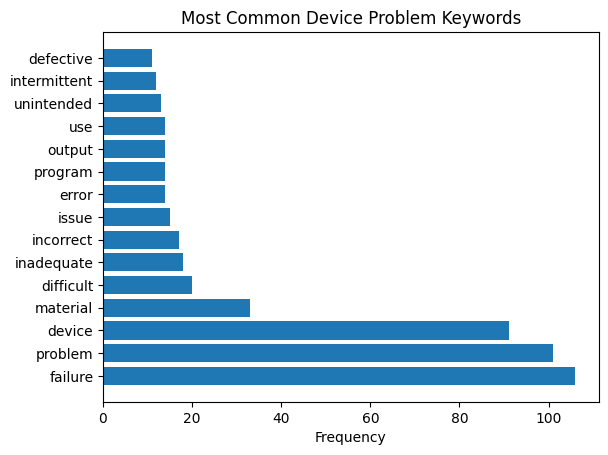

In [15]:
import matplotlib.pyplot as plt

common = Counter(words).most_common(15)

terms = [t[0] for t in common]
counts = [t[1] for t in common]

plt.barh(terms, counts)
plt.title("Most Common Device Problem Keywords")
plt.xlabel("Frequency")
plt.show()

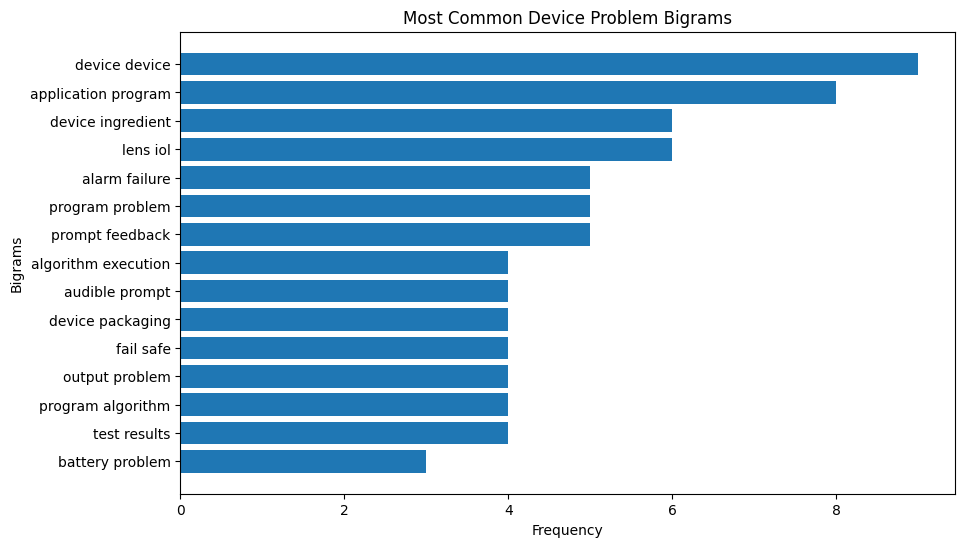

In [18]:
top_bigrams = bigrams.most_common(15)  
terms_b = [t[0] for t in top_bigrams]
counts_b = [t[1] for t in top_bigrams]

import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
plt.barh(terms_b[::-1], counts_b[::-1]) 
plt.title("Most Common Device Problem Bigrams")
plt.xlabel("Frequency")
plt.ylabel("Bigrams")
plt.show()